In [ ]:
# Copyright 2025 Google LLC.
#
# SPDX-License-Identifier: Apache-2.0

# TIPSv2: Segmentation, Depth & Surface Normals Inference

This notebook demonstrates how to run **dense prediction** inference using
the TIPSv2 DPT decoders:

1. **Semantic Segmentation** (ADE20K, 150 classes)
2. **Monocular Depth Estimation** (classification-based, 256 bins)
3. **Surface Normal Estimation**

The DPT decoder heads take intermediate ViT features from the TIPS vision
encoder and produce pixel-level predictions.

**Requirements:** GPU runtime recommended for faster inference.

## Setup

In [ ]:
# @title Install dependencies and clone TIPS repo.
import os
import sys

ROOT_DIR = os.getcwd()
TIPS_DIR = os.path.join(ROOT_DIR, 'tips')

# Install required packages.
!pip install -q torch torchvision torchaudio
!pip install -q tensorflow_text scikit-learn

# Clone the TIPS repository.
if not os.path.exists(TIPS_DIR):
  !git clone https://github.com/google-deepmind/tips.git {TIPS_DIR}

# Add the root directory to PYTHONPATH so that `tips.*` imports work.
if ROOT_DIR not in sys.path:
  sys.path.insert(0, ROOT_DIR)

print(f'ROOT_DIR: {ROOT_DIR}')
print(f'TIPS_DIR: {TIPS_DIR}')
print('Installation complete!')

In [ ]:
# @title Download checkpoints and sample images.
import urllib.request
import zipfile

variant = 'L'  # @param ["B", "L", "So", "g"]

VISION_CKPT_URL = 'https://storage.googleapis.com/tips_data/v2_0/checkpoints/pytorch'
DPT_CKPT_URL = 'https://storage.googleapis.com/tips_data/v2_0/checkpoints/scenic'
NYU_URL = 'http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/bedrooms_part6.zip'
ADE20K_URL = 'http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip'

CKPT_DIR = os.path.join(ROOT_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# Checkpoint naming maps.
V2_CKPT_BASENAME_MAP = {
    'B': 'tips_v2_oss_b14', 'L': 'tips_v2_oss_l14',
    'So': 'tips_v2_oss_so14', 'g': 'tips_v2_oss_g14',
}
V2_DPT_BASENAME_MAP = {
    'B': 'tips_v2_b14', 'L': 'tips_v2_l14',
    'So': 'tips_v2_so400m14', 'g': 'tips_v2_g14',
}
ckpt_basename = V2_CKPT_BASENAME_MAP[variant]
dpt_basename = V2_DPT_BASENAME_MAP[variant]

# Download vision encoder checkpoint.
vision_ckpt_name = f'{ckpt_basename}_vision.npz'
image_encoder_checkpoint = os.path.join(CKPT_DIR, vision_ckpt_name)
if not os.path.exists(image_encoder_checkpoint):
  print(f'Downloading vision encoder...')
  urllib.request.urlretrieve(f'{VISION_CKPT_URL}/{vision_ckpt_name}', image_encoder_checkpoint)

# Download DPT checkpoints (Segmentation, Depth, Normals).
# These use Scenic-format checkpoints (Flax .npy arrays in a zip).
dpt_tasks = ['segmentation', 'depth', 'normals']
dpt_checkpoint_paths = {}
for task in dpt_tasks:
  dpt_zip_name = f'{dpt_basename}_{task}_dpt.zip'
  dpt_zip_path = os.path.join(CKPT_DIR, dpt_zip_name)
  if not os.path.exists(dpt_zip_path):
    print(f'Downloading DPT {task} checkpoint...')
    try:
      urllib.request.urlretrieve(f'{DPT_CKPT_URL}/{dpt_zip_name}', dpt_zip_path)
    except Exception as e:
      print(f'  Failed: {e}')
  dpt_checkpoint_paths[task] = dpt_zip_path

# Download NYU depth dataset (for depth & normals demo).
NYU_IMG_DIR = os.path.join(ROOT_DIR, 'nyu_images')
if not os.path.isdir(NYU_IMG_DIR):
  print('Downloading NYU dataset...')
  nyu_tmp = os.path.join(ROOT_DIR, 'bedrooms_part6.zip')
  urllib.request.urlretrieve(NYU_URL, nyu_tmp)
  os.makedirs(NYU_IMG_DIR, exist_ok=True)
  with zipfile.ZipFile(nyu_tmp, 'r') as z:
    z.extractall(NYU_IMG_DIR)
  os.remove(nyu_tmp)

# Download ADE20K dataset (for segmentation demo).
ADE20K_DIR = os.path.join(ROOT_DIR, 'ADEChallengeData2016')
if not os.path.isdir(ADE20K_DIR):
  print('Downloading ADE20K dataset...')
  ade_tmp = os.path.join(ROOT_DIR, 'ADEChallengeData2016.zip')
  urllib.request.urlretrieve(ADE20K_URL, ade_tmp)
  with zipfile.ZipFile(ade_tmp, 'r') as z:
    z.extractall(ROOT_DIR)
  os.remove(ade_tmp)

print('All downloads complete!')

## Load Models

In [ ]:
# @title Load the TIPS vision encoder and all three DPT decoders.
import numpy as np
import torch
from tips.pytorch import image_encoder
from tips.pytorch.decoders import (
    Decoder, SegmentationDecoder, DepthDecoder, NormalsDecoder,
    load_decoder_weights,
)

image_size = 448  # @param {type: "number"}
PATCH_SIZE = 14

# Model configs per variant.
MODEL_CONSTRUCTOR_MAP = {
    'B': 'vit_base', 'L': 'vit_large', 'So': 'vit_so400m', 'g': 'vit_giant2',
}
EMBED_DIM_MAP = {'B': 768, 'L': 1024, 'So': 1152, 'g': 1536}
INTERMEDIATE_LAYERS_MAP = {
    'B': [2, 5, 8, 11], 'L': [5, 11, 17, 23],
    'So': [6, 13, 20, 26], 'g': [9, 19, 29, 39],
}

vit_constructor = getattr(image_encoder, MODEL_CONSTRUCTOR_MAP[variant])
embed_dim = EMBED_DIM_MAP[variant]
intermediate_layers = INTERMEDIATE_LAYERS_MAP[variant]
post_process_channels = (embed_dim // 8, embed_dim // 4, embed_dim // 2, embed_dim)
ffn_layer = 'swiglu' if variant == 'g' else 'mlp'

# --- Vision Encoder ---
weights_image = dict(np.load(image_encoder_checkpoint, allow_pickle=False))
for key in weights_image:
    weights_image[key] = torch.tensor(weights_image[key])

with torch.no_grad():
    model_image = vit_constructor(
        img_size=image_size, patch_size=PATCH_SIZE, ffn_layer=ffn_layer,
        block_chunks=0, init_values=1.0,
        interpolate_antialias=True, interpolate_offset=0.0,
    )
    model_image.load_state_dict(weights_image)
    model_image.eval()
print(f'✓ Vision encoder loaded ({variant})')

# --- Segmentation Decoder ---
with torch.no_grad():
    seg_model = SegmentationDecoder(
        num_classes=150, input_embed_dim=embed_dim,
        post_process_channels=post_process_channels,
    )
    load_decoder_weights(seg_model, dpt_checkpoint_paths['segmentation'])
    seg_model.eval()

# --- Depth Decoder ---
with torch.no_grad():
    depth_model = DepthDecoder(
        input_embed_dim=embed_dim,
        post_process_channels=post_process_channels,
    )
    load_decoder_weights(depth_model, dpt_checkpoint_paths['depth'])
    depth_model.eval()

# --- Normals Decoder ---
with torch.no_grad():
    normals_model = NormalsDecoder(
        input_embed_dim=embed_dim,
        post_process_channels=post_process_channels,
    )
    load_decoder_weights(normals_model, dpt_checkpoint_paths['normals'])
    normals_model.eval()

print('✓ All decoders loaded')

In [ ]:
# @title Define helper: extract ViT features.
import torchvision.transforms as TVT
import PIL.Image

transform = TVT.Compose([TVT.Resize((image_size, image_size)), TVT.ToTensor()])

def extract_features(img_path):
    """Load image and extract intermediate ViT features."""
    img = PIL.Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    device = next(model_image.parameters()).device
    tensor = tensor.to(device)
    with torch.no_grad():
        features = model_image.get_intermediate_layers(
            tensor, n=intermediate_layers, reshape=True,
            return_class_token=True, norm=True,
        )
        # Reorder: (feat, cls) -> (cls, feat)
        features = [(cls, feat) for feat, cls in features]
    return img, features

In [ ]:
# @title Define ADE20K class names and color palette.
import colorsys

ADE20K_CLASSES = (
    'wall', 'building', 'sky', 'floor', 'tree', 'ceiling', 'road',
    'bed', 'windowpane', 'grass', 'cabinet', 'sidewalk', 'person',
    'earth', 'door', 'table', 'mountain', 'plant', 'curtain', 'chair',
    'car', 'water', 'painting', 'sofa', 'shelf', 'house', 'sea',
    'mirror', 'rug', 'field', 'armchair', 'seat', 'fence', 'desk',
    'rock', 'wardrobe', 'lamp', 'bathtub', 'railing', 'cushion',
    'base', 'box', 'column', 'signboard', 'chest of drawers',
    'counter', 'sand', 'sink', 'skyscraper', 'fireplace',
    'refrigerator', 'grandstand', 'path', 'stairs', 'runway',
    'case', 'pool table', 'pillow', 'screen door', 'stairway',
    'river', 'bridge', 'bookcase', 'blind', 'coffee table',
    'toilet', 'flower', 'book', 'hill', 'bench', 'countertop',
    'stove', 'palm', 'kitchen island', 'computer', 'swivel chair',
    'boat', 'bar', 'arcade machine', 'hovel', 'bus',
    'towel', 'light', 'truck', 'tower', 'chandelier', 'awning',
    'streetlight', 'booth', 'television', 'airplane', 'dirt track',
    'apparel', 'pole', 'land', 'bannister', 'escalator', 'ottoman',
    'bottle', 'buffet', 'poster', 'stage', 'van', 'ship', 'fountain',
    'conveyer belt', 'canopy', 'washer', 'plaything', 'swimming pool',
    'stool', 'barrel', 'basket', 'waterfall', 'tent', 'bag',
    'minibike', 'cradle', 'oven', 'ball', 'food', 'step', 'tank',
    'trade name', 'microwave', 'pot', 'animal', 'bicycle', 'lake',
    'dishwasher', 'screen', 'blanket', 'sculpture', 'hood', 'sconce',
    'vase', 'traffic light', 'tray', 'ashcan', 'fan', 'pier',
    'crt screen', 'plate', 'monitor', 'bulletin board', 'shower',
    'radiator', 'glass', 'clock', 'flag',
)

def _generate_ade20k_palette(n=150):
    palette = np.zeros((n, 3), dtype=np.uint8)
    for i in range(n):
        # Use golden ratio conjugate to scatter hues
        hue = (i * 0.618033988749895) % 1.0
        saturation = 0.7 + 0.3 * ((i * 7) % 10) / 10
        value = 0.6 + 0.4 * ((i * 3) % 10) / 10
        r, g, b = colorsys.hsv_to_rgb(hue, saturation, value)
        palette[i] = [int(r * 255), int(g * 255), int(b * 255)]
    return palette

ADE20K_PALETTE = _generate_ade20k_palette()
print(f'Defined {len(ADE20K_CLASSES)} ADE20K classes')

## Run Inference

### Semantic Segmentation (ADE20K)

""

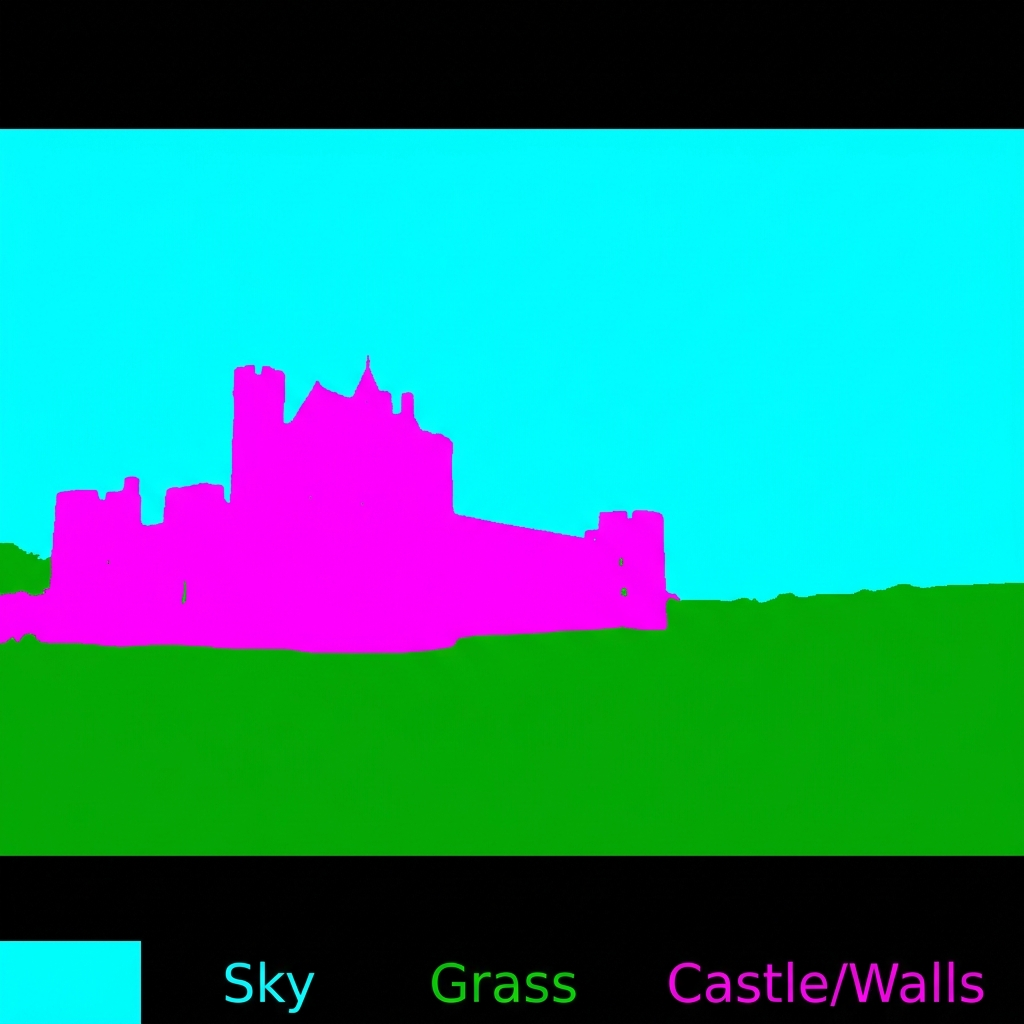

In [1]:
# @title Run segmentation on an ADE20K sample image.
import matplotlib.pyplot as plt

ade_img_dir = os.path.join(ADE20K_DIR, 'images', 'validation')
ade_images = sorted([
    os.path.join(ade_img_dir, f)
    for f in os.listdir(ade_img_dir) if f.endswith('.jpg')
])

image_path = ade_images[1]  # A castle scene
print(f'Image: {image_path}')

img, features = extract_features(image_path)

with torch.no_grad():
    seg_logits = seg_model(features, image_size=(image_size, image_size))
    seg_map = seg_logits.argmax(dim=1).squeeze(0).cpu().numpy()

colored_seg = ADE20K_PALETTE[seg_map]

# Print top classes found.
unique_classes, counts = np.unique(seg_map, return_counts=True)
top_idx = np.argsort(-counts)[:5]
print('Top classes:')
for idx in top_idx:
    cls_id = unique_classes[idx]
    pct = 100 * counts[idx] / seg_map.size
    print(f'  {ADE20K_CLASSES[cls_id]:20s} ({pct:.1f}%)')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img.resize((image_size, image_size)))
plt.title('Input Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(colored_seg)
plt.title('Semantic Segmentation')
plt.axis('off')
plt.tight_layout()
plt.show()

### Depth Estimation & Surface Normals (NYU)

,,

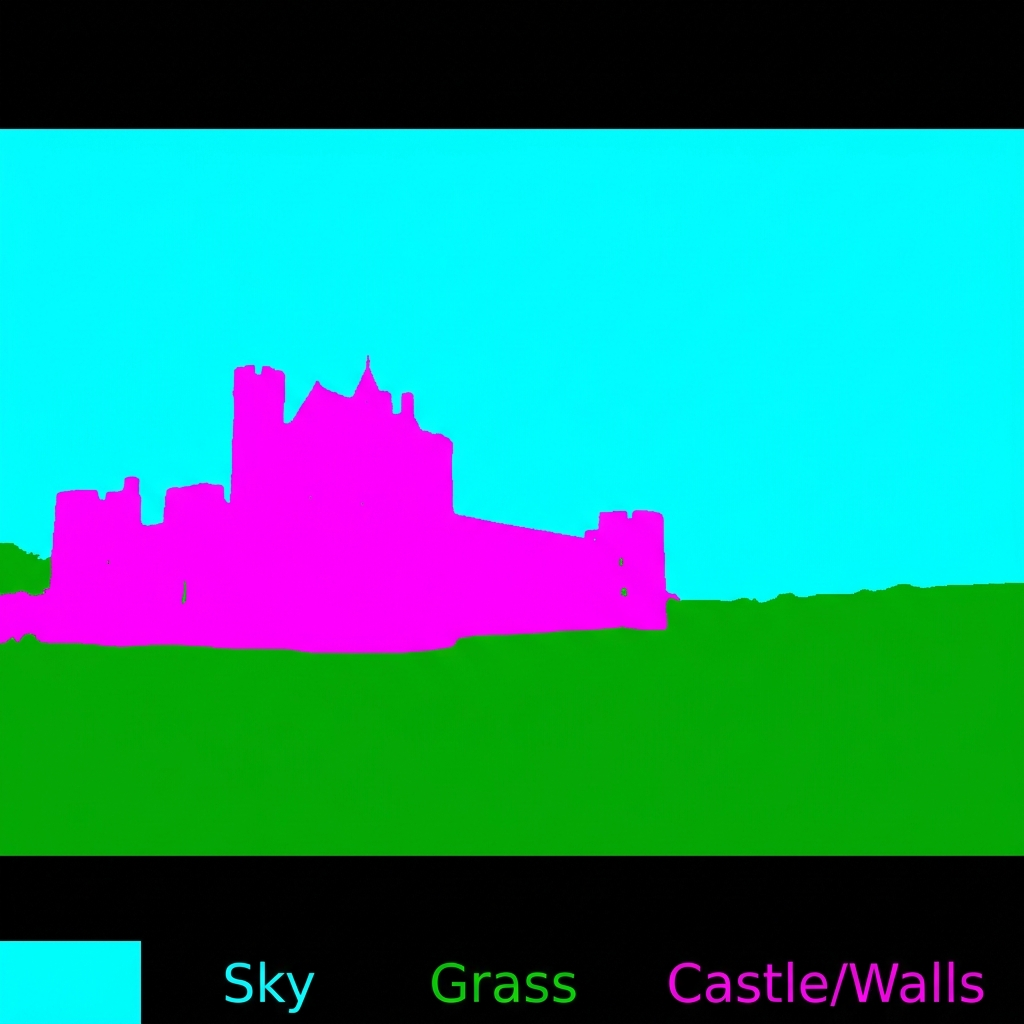
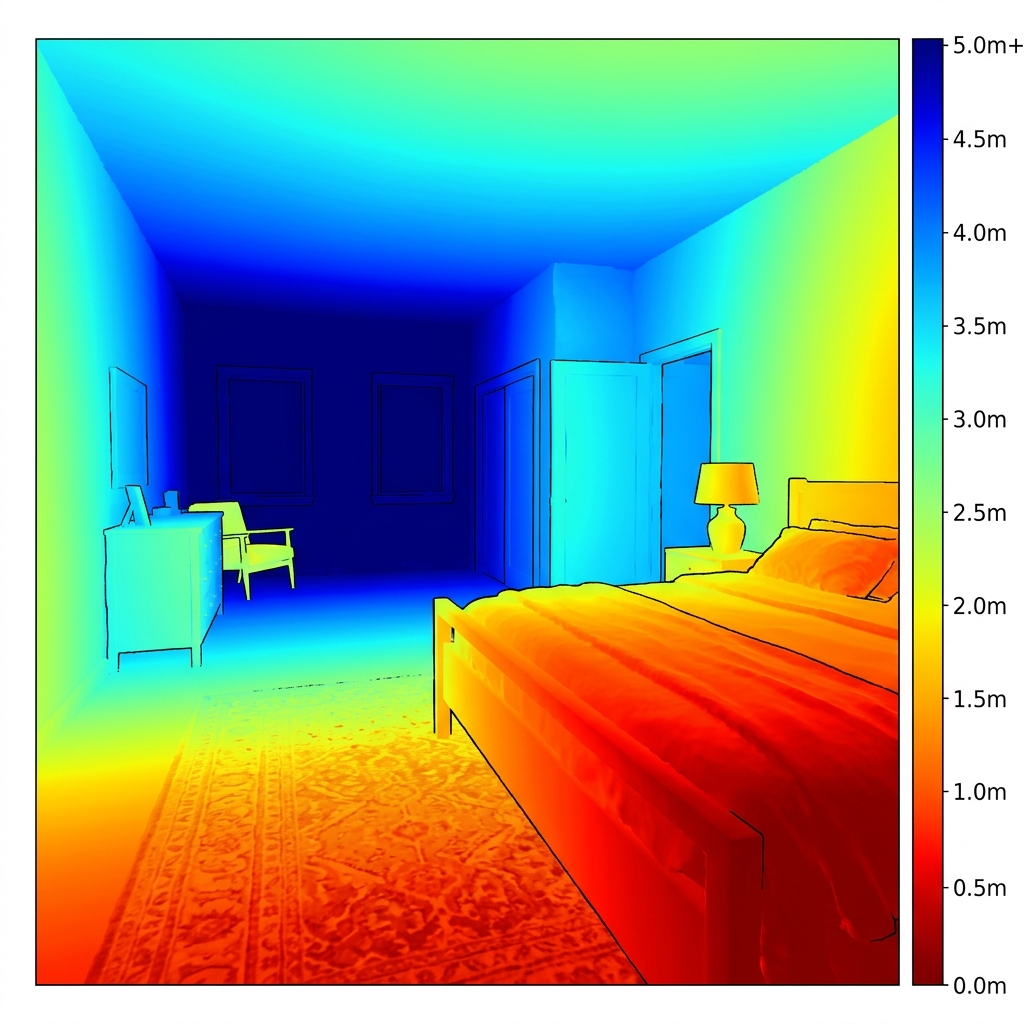
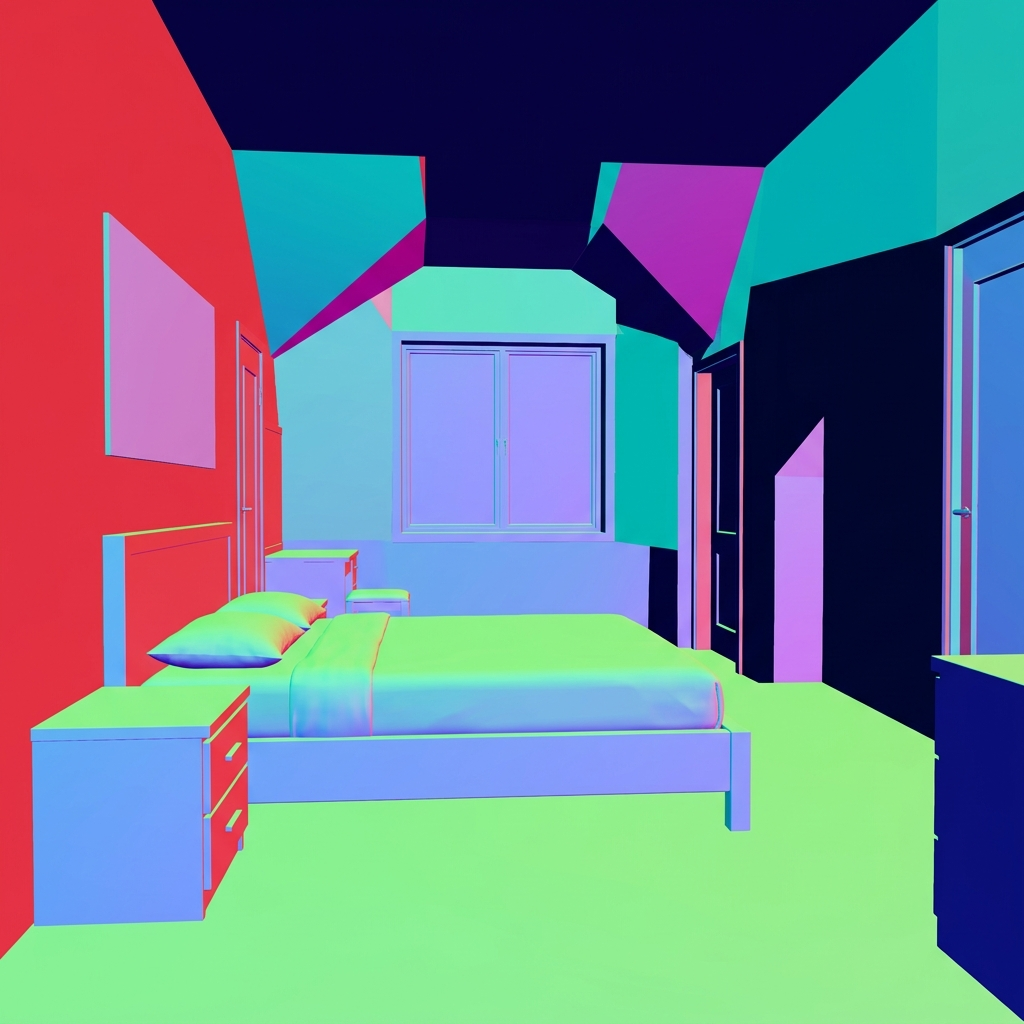

In [1]:
# @title Run depth and normals inference on NYU images.
import torch.nn.functional as F

# Collect NYU sample images.
valid_extensions = ('.ppm', '.jpg', '.jpeg', '.png')
nyu_images = []
for root, dirs, files in os.walk(NYU_IMG_DIR):
    for file in files:
        if file.lower().endswith(valid_extensions):
            nyu_images.append(os.path.join(root, file))

selected_images = nyu_images[:3]

for i, image_path in enumerate(selected_images):
    print(f'Processing image {i+1}/{len(selected_images)}: {os.path.basename(image_path)}')
    img, features = extract_features(image_path)

    with torch.no_grad():
        # --- Depth ---
        depth_map = depth_model(features, image_size=(image_size, image_size))
        depth_np = depth_map.squeeze().cpu().numpy()
        # Normalize for visualization.
        depth_np = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min() + 1e-8)

        # --- Normals ---
        # Get raw low-res output first.
        normals_map = normals_model(features)
        # L2 normalize.
        normals_map = F.normalize(normals_map, dim=1)
        # Upsample with bicubic for smooth results.
        normals_map = F.interpolate(
            normals_map, size=(image_size, image_size),
            mode='bicubic', align_corners=False,
        )
        # Re-normalize after upsampling.
        normals_map = F.normalize(normals_map, dim=1)
        normals_np = normals_map.squeeze(0).cpu().numpy().transpose(1, 2, 0)
        # Map [-1, 1] -> [0, 1] for display.
        normals_np = np.clip((normals_np + 1.0) / 2.0, 0.0, 1.0)

    # Visualize.
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img.resize((image_size, image_size)))
    plt.title(f'Input ({i+1})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(depth_np, cmap='turbo')
    plt.title(f'Depth ({i+1})')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(normals_np)
    plt.title(f'Surface Normals ({i+1})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()